In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib
import warnings
warnings.filterwarnings("ignore")

In [69]:
dataset = pd.read_csv("finance.csv")
dataset.head()

,transaction_id,customer_age,account_balance,transaction_amount,merchant_rating,credit_score,loan_amount,monthly_income,num_of_dependents,emi_amount,...,device_type,payment_mode,city,employment_type,loan_status,card_type,customer_segment,transaction_type,fraud_flag,target
0,1,56,328741.15,28543.38,2.8,395,338636.34,21525.11,5,42510.34,...,Tablet,Card,Delhi,Business,Approved,Gold,High,Offline,1,0
1,2,69,229911.81,2396.58,3.6,852,953144.05,75560.27,0,42696.69,...,Mobile,UPI,Nashik,Business,Approved,Silver,Low,Offline,0,0
2,3,46,136674.67,81390.53,4.2,855,875865.14,186823.33,1,14985.46,...,Laptop,Card,Nagpur,Salaried,Rejected,Platinum,High,Online,0,0
3,4,32,347078.85,77187.20,4.7,539,71270.02,153102.00,3,3292.47,...,Tablet,Wallet,Pune,Self-Employed,Rejected,Gold,High,Online,0,0
4,5,60,334438.19,87107.83,4.1,490,57372.41,72899.39,1,47930.60,...,Laptop,Card,Delhi,Self-Employed,Rejected,Platinum,Medium,Offline,0,0


In [70]:
dataset["target"].value_counts()

target
0    68132
1    11868
Name: count, dtype: int64

In [71]:
x = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [72]:
x.head()

,transaction_id,customer_age,account_balance,transaction_amount,merchant_rating,credit_score,loan_amount,monthly_income,num_of_dependents,emi_amount,...,risk_score,device_type,payment_mode,city,employment_type,loan_status,card_type,customer_segment,transaction_type,fraud_flag
0,1,56,328741.15,28543.38,2.8,395,338636.34,21525.11,5,42510.34,...,0.309,Tablet,Card,Delhi,Business,Approved,Gold,High,Offline,1
1,2,69,229911.81,2396.58,3.6,852,953144.05,75560.27,0,42696.69,...,0.750,Mobile,UPI,Nashik,Business,Approved,Silver,Low,Offline,0
2,3,46,136674.67,81390.53,4.2,855,875865.14,186823.33,1,14985.46,...,0.002,Laptop,Card,Nagpur,Salaried,Rejected,Platinum,High,Online,0
3,4,32,347078.85,77187.20,4.7,539,71270.02,153102.00,3,3292.47,...,0.448,Tablet,Wallet,Pune,Self-Employed,Rejected,Gold,High,Online,0
4,5,60,334438.19,87107.83,4.1,490,57372.41,72899.39,1,47930.60,...,0.816,Laptop,Card,Delhi,Self-Employed,Rejected,Platinum,Medium,Offline,0


In [73]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [74]:
numeric_feature = x.select_dtypes(exclude=["object"]).columns
catag_feature = x.select_dtypes(include=["object"]).columns

In [75]:
numeric_feature

Index(['transaction_id', 'customer_age', 'account_balance',
       'transaction_amount', 'merchant_rating', 'credit_score', 'loan_amount',
       'monthly_income', 'num_of_dependents', 'emi_amount', 'years_with_bank',
       'savings_amount', 'insurance_amount', 'investment_score', 'risk_score',
       'fraud_flag'],
      dtype='object')

In [76]:
catag_feature

Index(['device_type', 'payment_mode', 'city', 'employment_type', 'loan_status',
       'card_type', 'customer_segment', 'transaction_type'],
      dtype='object')

In [77]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [78]:
catag_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

In [79]:
preprocess_pipeline = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_feature),
    ("catag", catag_pipeline, catag_feature)
])

In [80]:
clean = preprocess_pipeline.fit(x)

In [81]:
Clean_data = pd.DataFrame(clean.transform(x))

In [82]:
Clean_data.head()

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,-1.732029,0.606848,0.546070,-0.749163,-0.177108,-1.176207,-0.568218,-1.640671,1.464414,1.199983,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.731986,1.396837,-0.140539,-1.654514,0.514906,1.464470,1.569496,-0.842861,-1.463609,1.213147,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,-1.731943,-0.000836,-0.788296,1.080705,1.033917,1.481805,1.300663,0.799898,-0.878004,-0.744430,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,-1.731899,-0.851593,0.673470,0.935161,1.466426,-0.344134,-1.498317,0.302015,0.293205,-1.570446,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-1.731856,0.849922,0.585650,1.278670,0.947415,-0.627270,-1.546663,-0.882148,-0.878004,1.582881,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0


In [83]:
joblib.dump(clean, "random_forest_preprocess_pipeline.pkl")

['random_forest_preprocess_pipeline.pkl']

In [84]:
joblib.load("random_forest_preprocess_pipeline.pkl")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('catag', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [85]:
x_train, x_test, y_train, y_test = train_test_split(
    Clean_data, y, test_size=0.2, random_state=42
)

In [86]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

In [87]:
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [88]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

In [89]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

In [90]:
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.851546875
Testing Accuracy: 0.8520625


In [91]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Confusion Matrix:
[[13633     0]
 [ 2367     0]]


In [92]:
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     13633
           1       0.00      0.00      0.00      2367

    accuracy                           0.85     16000
   macro avg       0.43      0.50      0.46     16000
weighted avg       0.73      0.85      0.78     16000



In [93]:
joblib.dump(model, "random_forest.pkl")

['random_forest.pkl']

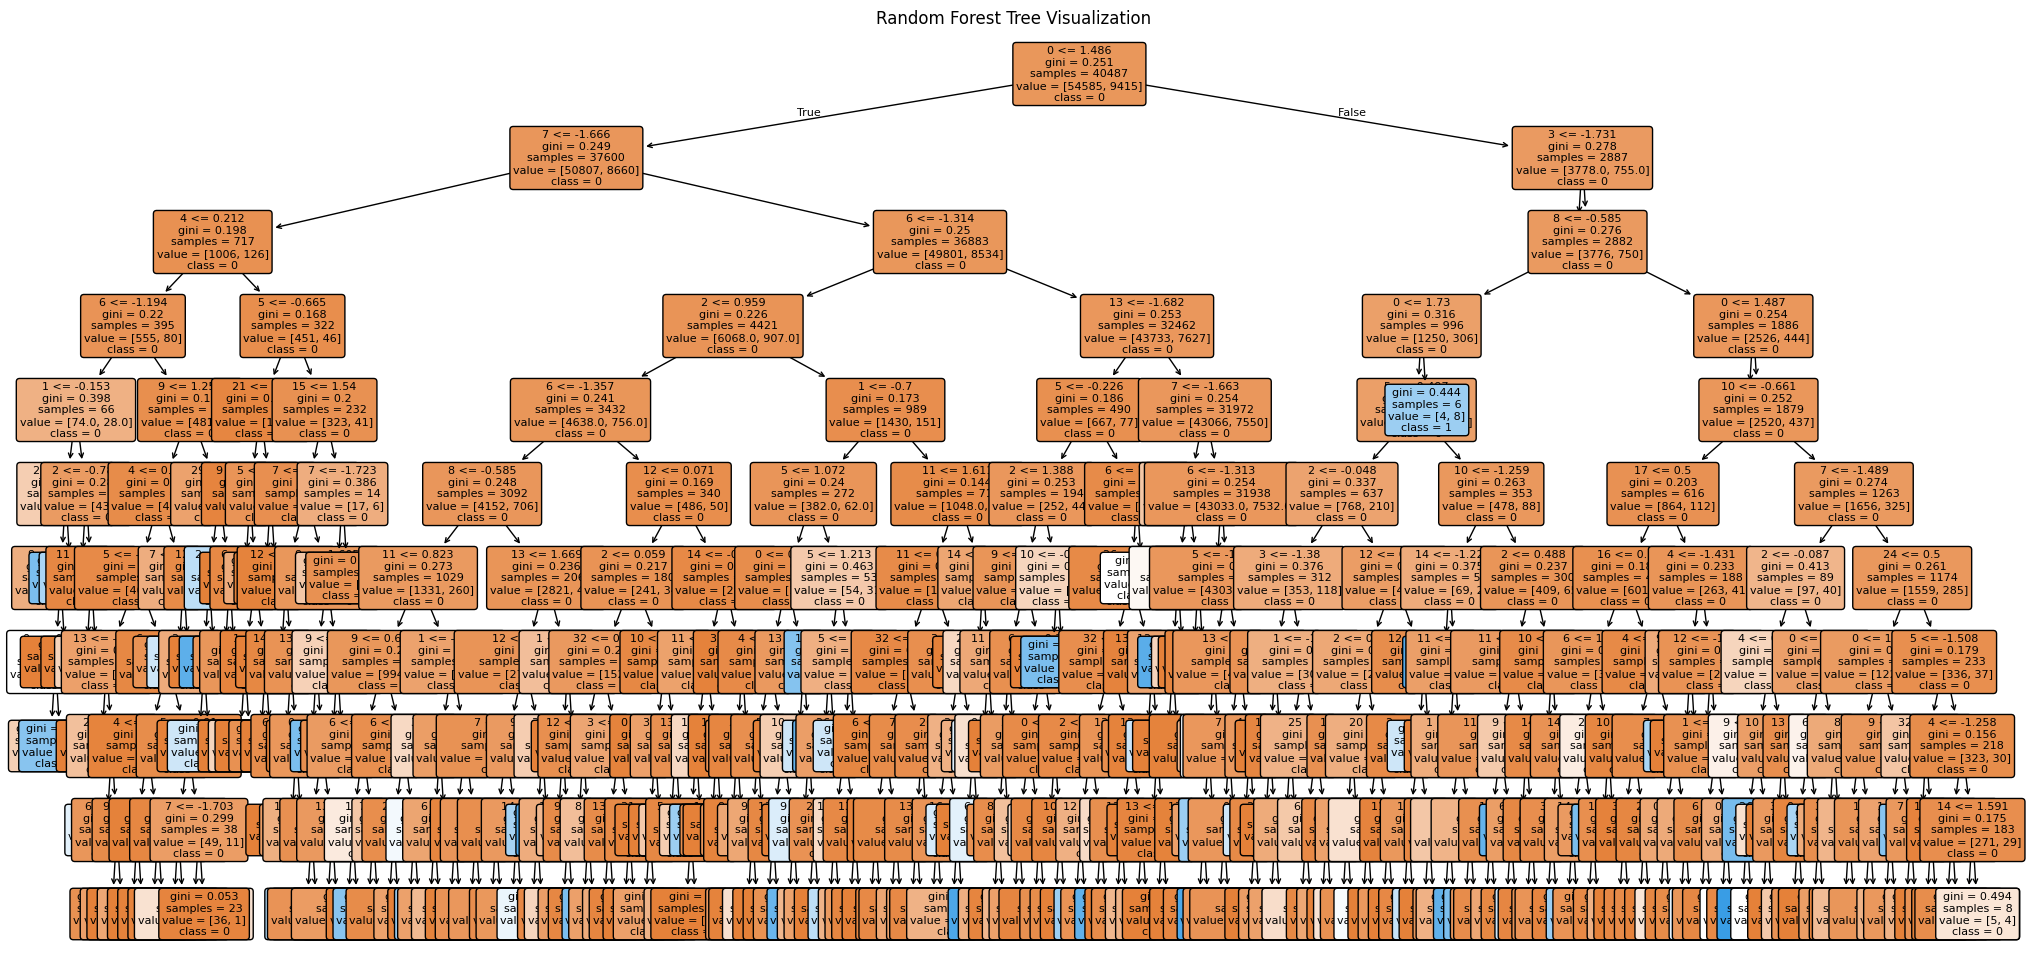

In [94]:
plt.figure(figsize=(25,12))

plot_tree(
    model.estimators_[0],   # first tree from random forest
    filled=True,
    rounded=True,
    fontsize=8,
    feature_names=x_train.columns,
    class_names=['0', '1']
)

plt.title("Random Forest Tree Visualization")

plt.show()